# Ranking receptors for a fixed epitope — the 22-cohort VDJdb panel

Which of these T-cell receptors reads this epitope? The input is a folder of co-folded complexes and
nothing else: no binding assay, no alignment to a known binder, and no number the generator emits.

This notebook runs the whole path — fetch, featurise, score — over the **balanced VDJdb receptor
benchmark**: 1,089 TCRmodel2 complexes over 22 epitope cohorts, 523 real VDJdb binders against 566
mock mispairings. It then reports the ranking **one cohort at a time**, because a macro average over
22 cohorts hides both of the facts that matter: a macro number cannot tell two strong cohorts and one
inverted cohort apart from twenty-two mediocre ones.

The covariate the result turns on is **template coverage** — whether *some* receptor, not necessarily
one appearing here, has already been co-crystallised with that peptide, and so whether the generator
had a template for the interface it was asked to build. Six of the 22 cohorts are covered and 16 are
free, and the two strata are never pooled.

**Needs**: the MHC allele reference (`tcren build-mhc-ref`, once) and about 4 GB of disk for the
structures. The featurisation pass is the expensive step; everything after it is arithmetic.


In [1]:
# Environment. Nothing here is stochastic -- there is no seed to set, because no score in this
# notebook samples: the transform, the class means and the covariance are all frozen in the wheel.
import platform, sys

import numpy as np
import polars as pl
import sklearn

import tcren

print(f"python     {platform.python_version()}")
print(f"tcren      {tcren.__version__}")
print(f"numpy      {np.__version__}")
print(f"polars     {pl.__version__}")
print(f"scikit     {sklearn.__version__}")


python     3.12.13
tcren      3.0.0
numpy      2.5.1
polars     1.43.0
scikit     1.9.0


## 1 · Bootstrap the deposit

The benchmark ships as one archive plus a `metadata.tsv` on the Hugging Face dataset
[`isalgo/tcren_structures`](https://huggingface.co/datasets/isalgo/tcren_structures), under
`vdjdb_binder_benchmark/`. The metadata carries the binder label `y`, the epitope and allele, the
generator's own `iptm` and `plddt`, and `native_structure_exists` — the template flag.

The cell is idempotent: it downloads and unpacks only what is missing.

In [2]:
# Fetch and unpack the 1,089-structure deposit into ../data (gitignored).
import os, tarfile, time
from pathlib import Path

from tcren.paper.bootstrap import fetch_hf_structures

DATA = Path(os.environ.get("TCREN_NB_DATA", "data"))
SET = DATA / "vdjdb_binder_benchmark"
PDBS = SET / "positives"

if not PDBS.is_dir():
    fetch_hf_structures(DATA, folders=("vdjdb_binder_benchmark",))
    with tarfile.open(SET / "vdjdb_binder_benchmark.tar.gz") as tar:
        tar.extractall(SET)

meta = pl.read_csv(SET / "metadata.tsv", separator="\t", infer_schema_length=None)
n_pdb = len(list(SET.glob("*/*.pdb")))
print(f"structures on disk       {n_pdb}")
print(f"metadata rows            {meta.height}")
print(f"binders / mock negatives {int(meta['y'].sum())} / {int((1 - meta['y']).sum())}")
print(f"epitope cohorts          {meta['epitope'].n_unique()}")
print(f"template-covered rows    {int(meta['native_structure_exists'].sum())} "
      f"of {meta.height}")


structures on disk       1089
metadata rows            1089
binders / mock negatives 523 / 566
epitope cohorts          22
template-covered rows    297 of 1089


## 2 · Featurise, once

`tcren features` is the expensive half of the pipeline: parse, annotate the TCR and MHC chains, build
the contact map, and compute all 164 catalogued descriptors. It is run once and its table is re-scored
for free.

The exact command, which is what regenerates the cached table:

```bash
tcren features -s "data/vdjdb_binder_benchmark/*/*.pdb" \
               -i placement,interface,topology,energetics,potts,kinetics \
               -t 0 -o data/vdjdb_binder_benchmark/features.tsv
```

`-t 0` uses every core. All six families are asked for, because the five score channels are marginals
of the descriptor families and `mechanics` needs `kinetics`. Measured here: **1,089 structures in 169 s
on 16 cores** (1,967 s of CPU); on four cores expect roughly twelve minutes. The cell below skips the pass
entirely when the table is already on disk, so re-running the notebook is cheap.

Every table `tcren features` writes carries a `.provenance.json` beside it recording the version, the
invocation and a SHA-256 digest of the descriptor catalogue. `tcren assess` refuses a table written
under a different catalogue rather than mixing generations.

In [3]:
# Descriptors, one row per structure. Skipped when the cached table is already present.
import subprocess

FEATURES = SET / "features.tsv"
FAMILIES = "placement,interface,topology,energetics,potts,kinetics"

if not FEATURES.exists():
    t0 = time.time()
    subprocess.run(
        [sys.executable, "-m", "tcren", "features", "-s", f"{SET}/*/*.pdb",
         "-i", FAMILIES, "-t", "0", "-o", str(FEATURES)],
        check=True, capture_output=True, text=True)
    print(f"featurised {n_pdb} structures in {time.time() - t0:.0f} s")

feats = pl.read_csv(FEATURES, separator="\t", infer_schema_length=None)
descriptor_cols = [c for c in feats.columns if c not in meta.columns and c != "complex.id"]
print(f"{feats.height} rows x {len(descriptor_cols)} descriptors")
print(f"metadata joined onto {int(feats['y'].is_not_null().sum())} of {feats.height} rows")


featurised 1089 structures in 169 s
1089 rows x 164 descriptors
metadata joined onto 1089 of 1089 rows


## 3 · Score

`tcren.score.score_table` returns every read-out of the frozen model for this table. All of them are
defined for **one** structure: the transform, the class means and the covariance were fitted on a
hold-out that ships inside the wheel, so nothing is estimated from the rows being scored and a score
does not move depending on what was scored beside it.

| read-out | tier | what is estimated |
|---|---|---|
| `peptide_score` | 0 | nothing; the direction is fixed by the potential |
| `pose_score` | 1 | a covariance over hold-out binders — no negative, no label |
| `confidence_residual` | 1 | the same covariance, read as a conditional mean |
| `binder_score` | 2 | class means and covariances, from hold-out binder labels |
| `channel_*` | 2 | the same object, marginalized to one descriptor family |

`binder_iptm` is `binder_score + logit(ipTM)`: two log-odds added, no coefficient to fit, still defined
for a single structure. Higher is better throughout.

From the command line the same table comes out of `tcren assess --features features.tsv -o scores.tsv`.

In [4]:
# Every read-out of the frozen hold-out model, in one call.
from tcren.score import CHANNELS, holdout_model, holdout_manifest, score_table

model = holdout_model()
scores = score_table(feats, iptm=feats["iptm"].to_numpy(), model=model)
panel = scores.with_columns(
    feats["epitope"], feats["mhc"], feats["y"],
    feats["native_structure_exists"].alias("covered"),
    feats["iptm"], feats["plddt"])

print(f"model: tcren {model.tcren_version}, {model.n_pos} binders / {model.n_neg} non-binders "
      f"over {model.n_epitopes} hold-out epitopes")
print(f"scored columns: {[c for c in scores.columns if c != 'complex.id']}")
panel.select("epitope", "y", "covered", "iptm", "pose_score", "binder_score",
             "binder_iptm", "confidence_residual").head(5)


model: tcren 3.0.0, 6429 binders / 1155 non-binders over 31 hold-out epitopes
scored columns: ['pose_score', 'binder_score', 'channel_placement', 'channel_interface', 'channel_shape', 'channel_energetics', 'channel_mechanics', 'peptide_score', 'confidence_residual', 'binder_iptm']


epitope,y,covered,iptm,pose_score,binder_score,binder_iptm,confidence_residual
str,i64,bool,f64,f64,f64,f64,f64
"""QAKWRLQTL""",0,false,0.8393508,-337.251593,-37.842933,-36.189528,-0.234271
"""RPIIRPATL""",0,false,0.8676005,-286.853361,-23.749557,-21.86965,-0.358769
"""FLRGRAYGL""",0,true,0.631656,-649.034789,-115.492025,-114.952699,-1.157456
"""QAKWRLQTL""",0,false,0.7751346,-355.210578,-32.535676,-31.298142,-0.095934
"""TPRVTGGGAM""",0,false,0.8708996,-390.091896,-46.326726,-44.41779,0.877601


### What the model was fitted on, and why this panel is a hold-out

The frozen coefficients are reproducible rather than merely stated: `holdout_manifest()` returns the
structures the fit used, with their dataset, epitope, label and ipTM, and `tcren fit-holdout`
regenerates the shipped arrays from them.

Two facts about the overlap, and they are different facts. **No structure in this panel contributed to
the fit** — the intersection of the two id sets is empty. **Eleven of the panel's 22 epitopes do appear
in the fit**, under other receptors; the model has seen those antigens, though never these complexes.
The template-free stratum is where that matters least and where the honest reading is.

In [5]:
# The fit's provenance, and the two overlaps stated apart.
man = holdout_manifest()
shared_ids = set(feats["complex.id"]) & set(man["pdb.id"])
shared_epitopes = sorted(set(feats["epitope"]) & set(man["epitope"]))

print(man.group_by("dataset").len().sort("len", descending=True))
print(f"\nstructures shared with the fit   {len(shared_ids)} of {feats.height}")
print(f"epitopes shared with the fit     {len(shared_epitopes)} of {feats['epitope'].n_unique()}")
print(f"  {', '.join(shared_epitopes)}")


shape: (4, 2)
┌─────────────────────────────┬──────┐
│ dataset                     ┆ len  │
│ ---                         ┆ ---  │
│ str                         ┆ u32  │
╞═════════════════════════════╪══════╡
│ VDJdb models — out-of-panel ┆ 6807 │
│ IMMREP23 negatives          ┆ 832  │
│ VDJdb free pool — re-paired ┆ 431  │
│ VDJdb free pool — cognate   ┆ 222  │
└─────────────────────────────┴──────┘

structures shared with the fit   0 of 1089
epitopes shared with the fit     11 of 22
  ATDALMTGF, AVFDRKSDAK, FLYALALLL, GILGFVFTL, GLCTLVAML, LLAGIGTVPI, LLWNGPMAV, NYNYLYRLF, RAKFKQLL, TPRVTGGGAM, YVLDHLIVV


## 4 · The ranking, one cohort at a time

Each epitope cohort is its own ranking problem: the receptors are ranked within the cohort and scored
against that cohort's own labels. Nothing is standardised across cohorts, and nothing is pooled.

Three arms on identical rows, which is the reporting rule this benchmark follows: the generator's
confidence alone, the structural read-out alone, and the two composed. A combination quoted without
both of its parts cannot be checked.

In [6]:
# Per-cohort ROC-AUC, one row per epitope. No pooling, no cross-cohort standardisation.
from sklearn.metrics import average_precision_score, roc_auc_score

ARMS = ["iptm", "plddt", "pose_score", "binder_score", "binder_iptm", "confidence_residual"] + [
    f"channel_{c}" for c in CHANNELS if f"channel_{c}" in panel.columns]


def per_cohort(table, arms=ARMS, metric=roc_auc_score):
    """One row per epitope: n, positives, the template flag, and `metric` for every arm."""
    out = []
    for epitope in sorted(set(table["epitope"])):
        g = table.filter(pl.col("epitope") == epitope)
        y = g["y"].to_numpy()
        row = {"epitope": epitope, "covered": bool(g["covered"][0]),
               "n": len(y), "n_pos": int(y.sum())}
        for a in arms:
            v = g[a].to_numpy().astype(float)
            ok = np.isfinite(v)
            row[a] = metric(y[ok], v[ok]) if ok.sum() > 2 and len(set(y[ok])) == 2 else np.nan
        out.append(row)
    return pl.DataFrame(out).sort(["covered", "epitope"], descending=[True, False])


roc = per_cohort(panel)
pl.Config.set_tbl_rows(30)
roc.select("epitope", "covered", "n", "n_pos", "iptm", "binder_score", "binder_iptm",
           "channel_shape")


epitope,covered,n,n_pos,iptm,binder_score,binder_iptm,channel_shape
str,bool,i64,i64,f64,f64,f64,f64
"""ELAGIGILTV""",true,65,32,0.875947,0.540948,0.549569,0.546336
"""FLRGRAYGL""",true,52,26,0.372781,0.563077,0.56,0.743077
"""GILGFVFTL""",true,46,23,0.94707,0.931677,0.931677,0.925466
"""GLCTLVAML""",true,40,20,0.6125,0.802778,0.802778,0.636111
"""NYNYLYRLF""",true,58,27,0.623656,0.678571,0.677198,0.652473
"""SLYNTVATL""",true,36,14,0.717532,0.685714,0.689286,0.678571
"""ATDALMTGF""",false,46,23,0.705104,0.727891,0.730159,0.650794
"""AVFDRKSDAK""",false,50,25,0.3552,0.414322,0.414322,0.409207
"""CLGGLLTMV""",false,46,23,0.359168,0.557656,0.555766,0.478261


### The two strata, reported apart

The median over cohorts and the count of cohorts beating no-skill, per stratum. The clearance count is
the part a macro mean throws away: it says how many of the individual ranking problems the arm actually
solves, and the target on this panel is more than 60 % cleared. For ROC-AUC no-skill is 0.50; the same
helper is reused below for average precision, where no-skill is the cohort's own prevalence instead.


In [7]:
# Median per-cohort score and cohorts cleared, template-covered against template-free.
# "Cleared" is judged against the arm's own no-skill value: 0.50 for ROC-AUC, and the cohort's
# own positive prevalence for average precision, which is not 0.50 and differs cohort to cohort.
def stratum_summary(table, arms=ARMS, baseline="roc"):
    """Per stratum and arm: the median over cohorts, and how many cohorts beat no-skill."""
    ref = (np.full(table.height, 0.5) if baseline == "roc"
           else table["n_pos"].to_numpy() / table["n"].to_numpy())
    table = table.with_columns(pl.Series("no_skill", ref))
    out = []
    for covered in (True, False):
        sub = table.filter(pl.col("covered") == covered)
        for a in arms:
            v = sub[a].to_numpy()
            out.append({"stratum": "template-covered" if covered else "template-free",
                        "cohorts": sub.height, "arm": a,
                        "median": float(np.nanmedian(v)),
                        "cleared": int(np.nansum(v > sub["no_skill"].to_numpy()))})
    return pl.DataFrame(out)


summary = stratum_summary(roc)
pl.Config.set_tbl_rows(40)
summary


stratum,cohorts,arm,median,cleared
str,i64,str,f64,i64
"""template-covered""",6,"""iptm""",0.670594,5
"""template-covered""",6,"""plddt""",0.731212,5
"""template-covered""",6,"""pose_score""",0.713462,5
"""template-covered""",6,"""binder_score""",0.682143,6
"""template-covered""",6,"""binder_iptm""",0.683242,6
"""template-covered""",6,"""confidence_residual""",0.594324,5
"""template-covered""",6,"""channel_placement""",0.624761,4
"""template-covered""",6,"""channel_interface""",0.673071,6
"""template-covered""",6,"""channel_shape""",0.665522,6


Two readings, and they are the result this benchmark exists for.

**Where a template exists, the structure and the confidence carry different evidence and compose.** The
posterior clears 0.50 in every covered cohort, and so does the composition with ipTM.

**Where no template exists, the generator's confidence falls to near a coin and does not warn you.**
The structural read-outs do not fall as far: the posterior and the one-class pose distance both stay
above ipTM's median, and the **shape channel is the strongest single arm on this stratum** — the
footprint's shape is invariant under the rigid-body placement the co-folding model is optimising,
which is why it still says something once that model has produced a confident pose.

## 5 · Which part of the structure says so — the five channels

A marginal of a Gaussian is a sub-block of its covariance: exact, closed form, no re-fit. So asking
which family of descriptors carries the signal costs an index and nothing else. The five channels are
`placement` (where the receptor sits in the groove frame), `interface` (how much interface it makes, of
what chemistry), `shape` (the footprint free of its size), `energetics` (the contact chemistry in kT)
and `mechanics` (the interface as a network of breakable springs).

They do not sum to `binder_score` and should not: the whole model also reads the correlations *between*
channels, which a per-channel view cannot show. What they give is attribution — and sometimes a better
instrument, where the whole model dilutes a channel that is carrying the cohort on its own.

In [8]:
# The five channels per cohort, and their per-stratum medians beside the full posterior.
channel_cols = [f"channel_{c}" for c in CHANNELS if f"channel_{c}" in panel.columns]
roc.select(["epitope", "covered", *channel_cols, "binder_score"])


epitope,covered,channel_placement,channel_interface,channel_shape,channel_energetics,channel_mechanics,binder_score
str,bool,f64,f64,f64,f64,f64,f64
"""ELAGIGILTV""",true,0.568966,0.695043,0.546336,0.710129,0.580819,0.540948
"""FLRGRAYGL""",true,0.232308,0.706154,0.743077,0.618462,0.447692,0.563077
"""GILGFVFTL""",true,0.778468,0.784679,0.925466,0.910973,0.807453,0.931677
"""GLCTLVAML""",true,0.680556,0.611111,0.636111,0.622222,0.747222,0.802778
"""NYNYLYRLF""",true,0.721154,0.651099,0.652473,0.70467,0.651099,0.678571
"""SLYNTVATL""",true,0.496429,0.603571,0.678571,0.678571,0.889286,0.685714
"""ATDALMTGF""",false,0.650794,0.53288,0.650794,0.503401,0.609977,0.727891
"""AVFDRKSDAK""",false,0.478261,0.483376,0.409207,0.603581,0.526854,0.414322
"""CLGGLLTMV""",false,0.599244,0.415879,0.478261,0.586011,0.499055,0.557656


In [9]:
# Channel medians per stratum, sorted, against the full posterior on the same rows.
for covered in (True, False):
    sub = roc.filter(pl.col("covered") == covered)
    label = "template-covered" if covered else "template-free"
    print(f"{label} ({sub.height} cohorts)")
    ranked = sorted(((float(np.nanmedian(sub[c].to_numpy())), c)
                     for c in [*channel_cols, "binder_score", "iptm"]), reverse=True)
    for value, name in ranked:
        cleared = int(np.nansum(sub[name].to_numpy() > 0.5))
        print(f"    {name:22s} median ROC-AUC {value:.3f}   cleared {cleared}/{sub.height}")
    print()


template-covered (6 cohorts)
    channel_mechanics      median ROC-AUC 0.699   cleared 5/6
    channel_energetics     median ROC-AUC 0.692   cleared 6/6
    binder_score           median ROC-AUC 0.682   cleared 6/6
    channel_interface      median ROC-AUC 0.673   cleared 6/6
    iptm                   median ROC-AUC 0.671   cleared 5/6
    channel_shape          median ROC-AUC 0.666   cleared 6/6
    channel_placement      median ROC-AUC 0.625   cleared 4/6

template-free (16 cohorts)
    channel_shape          median ROC-AUC 0.637   cleared 13/16
    binder_score           median ROC-AUC 0.615   cleared 11/16
    channel_energetics     median ROC-AUC 0.581   cleared 11/16
    iptm                   median ROC-AUC 0.525   cleared 9/16
    channel_mechanics      median ROC-AUC 0.525   cleared 10/16
    channel_placement      median ROC-AUC 0.505   cleared 8/16
    channel_interface      median ROC-AUC 0.500   cleared 8/16



## 6 · The panel, drawn

One point per cohort per arm, with the 0.50 line marked. The two strata are drawn on separate axes
because they are separate claims.

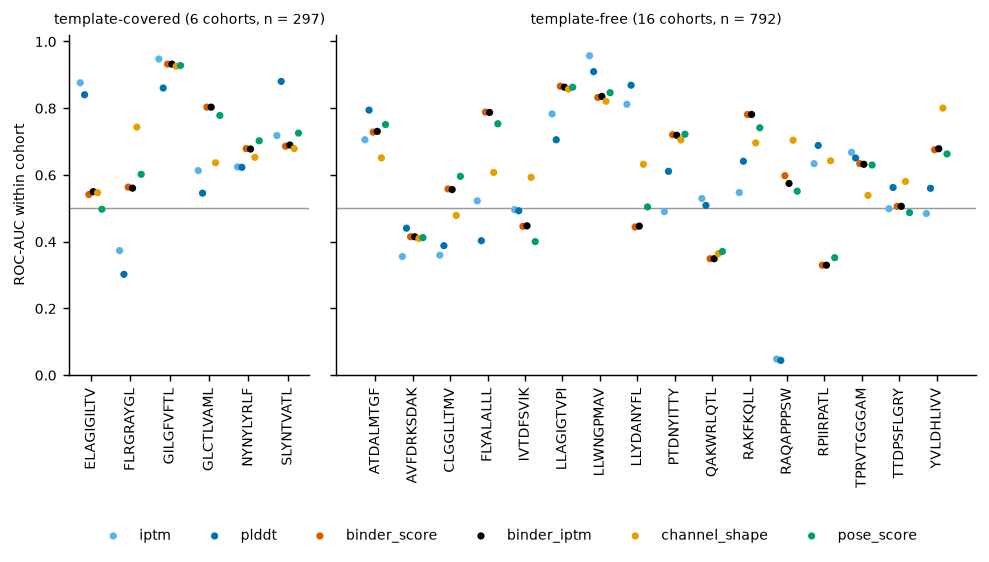

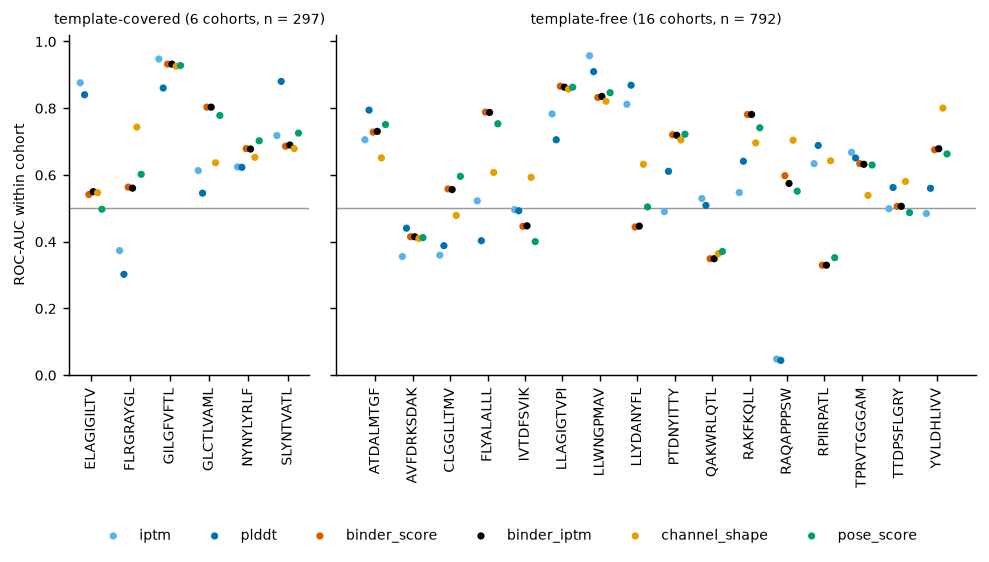

In [10]:
%matplotlib inline
# Per-cohort ROC-AUC by stratum: one point per cohort, 0.50 marked. Okabe-Ito palette.
import matplotlib.pyplot as plt

PLOT_ARMS = ["iptm", "plddt", "binder_score", "binder_iptm", "channel_shape", "pose_score"]
OKABE = {"iptm": "#56B4E9", "plddt": "#0072B2", "binder_score": "#D55E00",
         "binder_iptm": "#000000", "channel_shape": "#E69F00", "pose_score": "#009E73"}

plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 130})
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.4), sharey=True,
                         gridspec_kw={"width_ratios": [6, 16], "wspace": 0.06})

for ax, covered in zip(axes, (True, False)):
    sub = roc.filter(pl.col("covered") == covered)
    x = np.arange(sub.height)
    for k, arm in enumerate(PLOT_ARMS):
        ax.scatter(x + (k - 2.5) * 0.11, sub[arm].to_numpy(), s=16, color=OKABE[arm],
                   label=arm if covered else None, zorder=3, edgecolor="none")
    ax.axhline(0.5, color="0.6", lw=0.8, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["epitope"].to_list(), rotation=90)
    ax.set_title(f"{'template-covered' if covered else 'template-free'} "
                 f"({sub.height} cohorts, n = {int(sub['n'].sum())})", fontsize=8)
    ax.set_ylim(0.0, 1.02)

axes[0].set_ylabel("ROC-AUC within cohort")
fig.legend(loc="lower center", ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.30))
fig


## 7 · Precision, and where the ranking is used

ROC-AUC is the right read-out when the whole ordering matters. When only the head of the list will be
tested, average precision is the one to quote, and both are reported here on identical rows so neither
has to be taken on trust.

In [11]:
# The same cohorts under average precision, so the head-of-list behaviour is visible too.
# Clearance is against each cohort's own prevalence here, never against 0.50.
pr = per_cohort(panel, metric=average_precision_score)
pr_summary = stratum_summary(pr, baseline="prevalence")
print("cohort prevalence: "
      f"{(roc['n_pos'] / roc['n']).min():.3f} to {(roc['n_pos'] / roc['n']).max():.3f}")
pr_summary.filter(pl.col("arm").is_in(["iptm", "binder_score", "binder_iptm", "channel_shape"]))


cohort prevalence: 0.233 to 0.510


stratum,cohorts,arm,median,cleared
str,i64,str,f64,i64
"""template-covered""",6,"""iptm""",0.660167,5
"""template-covered""",6,"""binder_score""",0.632943,6
"""template-covered""",6,"""binder_iptm""",0.636079,6
"""template-covered""",6,"""channel_shape""",0.650774,6
"""template-free""",16,"""iptm""",0.553205,11
"""template-free""",16,"""binder_score""",0.608867,11
"""template-free""",16,"""binder_iptm""",0.607768,11
"""template-free""",16,"""channel_shape""",0.648556,13


## What this notebook establishes

- The whole path runs from deposited coordinates: fetch, `tcren features`, `tcren.score.score_table`.
  No binding assay is read at any point, and no structure scored here entered the frozen fit.
- The panel is reported **case by case over 22 cohorts**, template-covered and template-free apart. A
  macro average over the two strata is a Simpson artefact on this benchmark and is not quoted.
- The five channels attribute a score to a part of the structure, at the cost of one index into a
  covariance, and on the template-free stratum the shape channel is the strongest single arm.

**What it does not claim.** Not affinity: the score set ranks specificity, and what a static interface
reads of dynamics is the off-rate rather than the equilibrium constant. Not a substitute for reporting
template coverage: nothing computable from the model announces which regime a cohort is in — the
generator's confidence least of all — so template availability is a covariate to report, never one to
infer.

See `docs/assess.rst` for the read-outs one at a time, and `rank_peptides_cpl.ipynb` for the other
ranking task: peptides against a fixed receptor.